In [26]:
import pandas as pd
import pandas as pd
import numpy as np
import xgboost as xgb
import holidays
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('pos_sales_merged_with_competitor.csv')

In [27]:
df.head()

,order_id,sale_id,date,sales_channel,product_type,product,net_quantity,gross_sales,discounts,net_sales,...,peekaboo_min_price,min_price_across_sources,max_price_across_sources,cumulative_index,historical_min_competitor_price,historical_max_competitor_price,historical_jumia_price,historical_totshoppe_price,historical_peekaboo_price,historical_average_competitor_price
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,Online Store,bathing and skin care,mamia sensitive bathing and skin care 64 bathi...,1,200.0,0.0,200.0,...,250.0,250.0,250.0,1.0529,178.0,178.0,178.0,178.0,178.0,178.000000
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,Point of Sale,baby formula,nannycare growing up milk goat milk based 3 fr...,2,9000.0,0.0,9000.0,...,9999.0,9999.0,9999.0,1.0529,7108.0,7108.0,7108.0,7108.0,7108.0,7108.000000
2,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0,2639.666667
3,2864504438936,8752091201688,2020-11-16 16:56:04+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0,2639.666667
4,2864509321368,8752103653528,2020-11-16 16:59:30+03:00,Point of Sale,baby formula,aptamil stage 1 first infant milk powder 800 g,1,3000.0,0.0,3000.0,...,3540.0,3540.0,3800.0,1.0529,2517.0,2701.0,2701.0,2701.0,2517.0,2639.666667


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5853 entries, 0 to 5852
Data columns (total 30 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   order_id                             5853 non-null   int64  
 1   sale_id                              5853 non-null   int64  
 2   date                                 5853 non-null   object 
 3   sales_channel                        5853 non-null   object 
 4   product_type                         5853 non-null   object 
 5   product                              5853 non-null   object 
 6   net_quantity                         5853 non-null   int64  
 7   gross_sales                          5853 non-null   float64
 8   discounts                            5853 non-null   float64
 9   net_sales                            5853 non-null   float64
 10  total_sales                          5853 non-null   float64
 11  month                         

Using 20 numerical columns for correlation


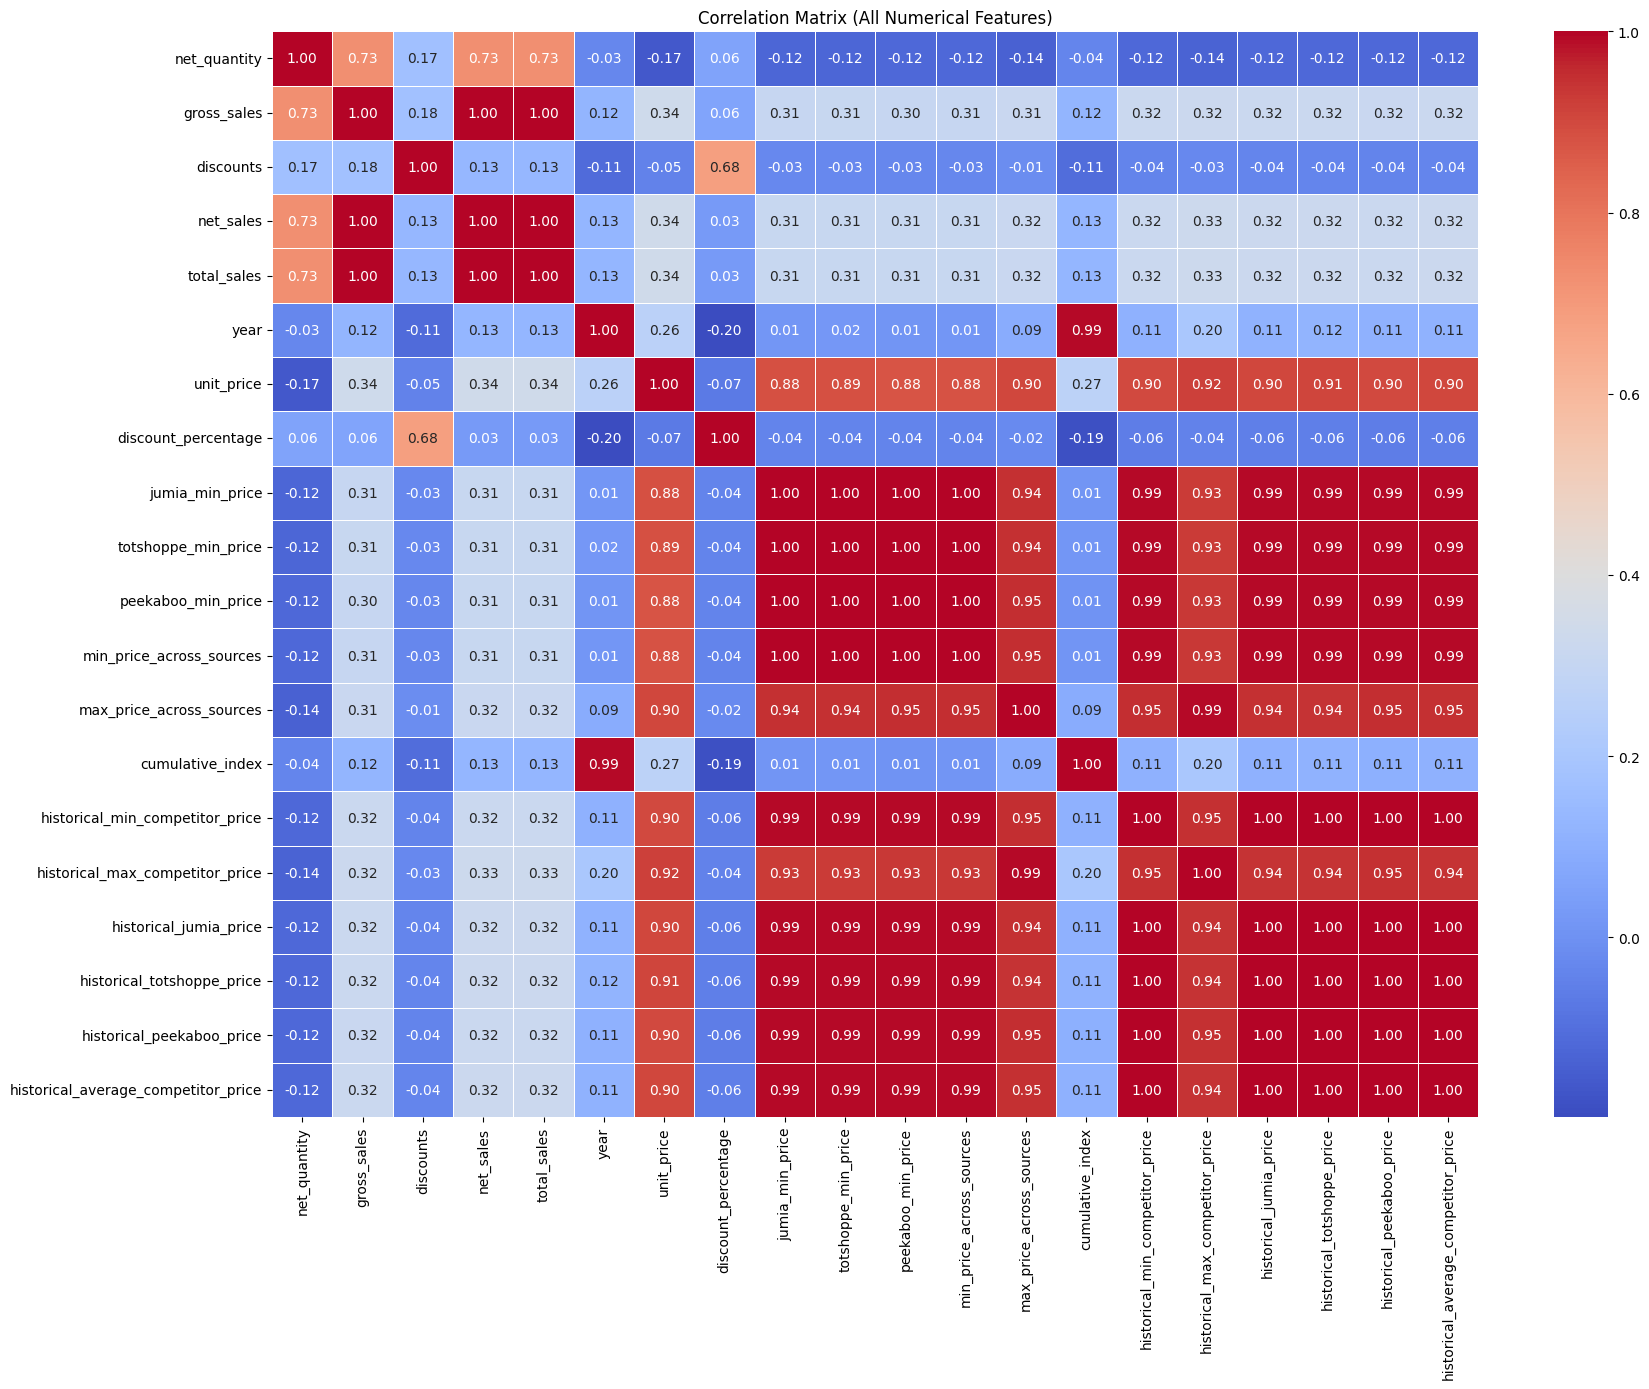

In [29]:
##Feature selection, drop features with high multicollinearity

import matplotlib.pyplot as plt
import seaborn as sns

# 4. Automatically select all numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Optional: drop columns you don't want (e.g., IDs)
exclude_cols = ['order_id', 'sale_id']  # e.g., ['id']
numerical_df = numerical_df.drop(columns=[col for col in exclude_cols if col in numerical_df.columns])

# Check
print(f"Using {numerical_df.shape[1]} numerical columns for correlation")

# Compute correlation matrix
correlation_matrix = numerical_df.corr()

# 5. Plot heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlation Matrix (All Numerical Features)')
plt.tight_layout()
plt.show()

In [30]:
print("Identifying and dropping redundant features...")

# List of features to drop
features_to_drop = [
    'order_id', # Unique identifier, not useful for modeling trends
    'sale_id',  # Unique identifier, not useful for modeling trends
    'month',    # Redundant with 'month_of_year' (numerical)
    'weekday',  # Redundant with 'day_of_week' (numerical)
    'net_sales', # Likely redundant with 'quantity * unit_price'
    'gross_sales', # Highly correlated with 'net_sales' and often derivable
    'total_sales', # Likely redundant with 'net_sales'
    'discounts', # Highly correlated with 'discount_percentage'
    'cumulative_index', # Highly correlated with 'net_sales'
    'sales_channel', # Unique identifier, not useful for modeling trends
    'cleaned_product_name', # High cardinality string, 'product_type' is a good summary
    'matched_user_product_original', # High cardinality string, 'product_type' is a good summary
    'jumia_min_price', # used for historical price simulation
    'totshoppe_min_price', # used for historical price simulation
    'peekaboo_min_price', # used for historical price simulation
    'min_price_across_sources', # used for historical price simulation
    'max_price_across_sources', # used for historical price simulation
    'historical_jumia_price', # related to historical average
    'historical_totshoppe_price', # related to historical average
    'historical_peekaboo_price', # related to historical average 
    'historical_min_competitor_price', # related to historical average   
    'historical_max_competitor_price' # related to historical average              
]

# Drop the identified features if they exist in the DataFrame
existing_features_to_drop = [col for col in features_to_drop if col in df.columns]
df = df.drop(columns=existing_features_to_drop)

print("Redundant features dropped successfully.")
print("\nDataFrame Info after dropping redundant features:")
df.info()

Identifying and dropping redundant features...
Redundant features dropped successfully.

DataFrame Info after dropping redundant features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5853 entries, 0 to 5852
Data columns (total 8 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   date                                 5853 non-null   object 
 1   product_type                         5853 non-null   object 
 2   product                              5853 non-null   object 
 3   net_quantity                         5853 non-null   int64  
 4   year                                 5853 non-null   int64  
 5   unit_price                           5853 non-null   float64
 6   discount_percentage                  5853 non-null   float64
 7   historical_average_competitor_price  5853 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 365.9+ KB


In [31]:
def prepare_weekly_data(df_original):
    df = df_original.copy()
    
    # 1. Ensure correct types
    df['date'] = pd.to_datetime(df['date'])

    # 2. Standardize to Weekly (Mondays)
    df['week_start'] = df['date'].dt.to_period('W').dt.start_time

    # 3. Aggregation Dictionary
    agg_dict = {
        'net_quantity': 'sum',
        'unit_price': 'mean',
        'discount_percentage': 'mean',
        'historical_average_competitor_price': 'mean'
    }

    # Group by both Product and the new Week column
    df_weekly = df.groupby(['product', 'product_type', 'week_start']).agg(agg_dict).reset_index()
    df_weekly = df_weekly.rename(columns={'week_start': 'date'}).sort_values(['product', 'date'])

    # 4. Feature Engineering
    df_weekly['year'] = df_weekly['date'].dt.year
    df_weekly['week_of_year'] = df_weekly['date'].dt.isocalendar().week.astype(int)

    ke_holidays = holidays.Kenya(years=[2020, 2021, 2022, 2023, 2024])
    def get_holiday_features(dt):
        h_name = ke_holidays.get(dt)
        return h_name
    df_weekly['holiday_name'] = df_weekly['date'].apply(get_holiday_features)
    df_weekly['is_holiday'] = df_weekly['holiday_name'].notnull().astype(int)

    # 4. Create the "Pre-Holiday" flag (Day before)

    df_weekly['is_pre_holiday'] = df_weekly['date'].apply(lambda x: 1 if (x + pd.Timedelta(days=1)) in ke_holidays else 0)
  
    df_weekly = df_weekly.drop(columns=['holiday_name'])
    
    # Lagged features (Look-back)
    grouped = df_weekly.groupby('product')
    for i in [1]:
        df_weekly[f'net_quantity_lag_{i}'] = grouped['net_quantity'].shift(i)
        df_weekly[f'unit_price_lag_{i}'] = grouped['unit_price'].shift(i)

    # Competitor Price Gap (How much cheaper/more expensive were we than the average competitor?)
    df_weekly['competitor_gap'] = df_weekly['unit_price'] - df_weekly['historical_average_competitor_price']

    # Rolling 4-week mean to capture recent momentum
    for i in [4]:
       df_weekly[f'rolling_mean_net_quantity_{i}w'] = grouped['net_quantity'].transform(lambda x: x.shift(1).rolling(window=i, min_periods=1).mean())
       df_weekly[f'rolling_median_net_quantity_{i}w'] = grouped['net_quantity'].transform(lambda x: x.shift(1).rolling(window=i, min_periods=1).median())
	  
    # 2. Price vs Own History     
    df_weekly['price_vs_avg_ratio'] = df_weekly['unit_price'] / (grouped['unit_price'].transform('mean') + 1e-6)    

    # We fill NaNs using the median of that SPECIFIC product.  
    cols_to_fill = [col for col in df_weekly.columns if 'lag' in col or 'rolling' in col or 'gap' in col]
    
    for col in cols_to_fill:
        df_weekly[col] = df_weekly.groupby('product')[col].transform(lambda x: x.fillna(x.median() if not x.isna().all() else 0))

    # Final fallback for products with only 1 row of data
    df_weekly = df_weekly.fillna(0)
    
    return df_weekly


In [32]:
#  PREPARE WEEKLY DATA ---
df_weekly = prepare_weekly_data(df) 
df_weekly = df_weekly.sort_values('date')

C:\Users\eerkmem\AppData\Local\Temp\ipykernel_19304\1261450464.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week_start'] = df['date'].dt.to_period('W').dt.start_time


Using 14 numerical columns for correlation


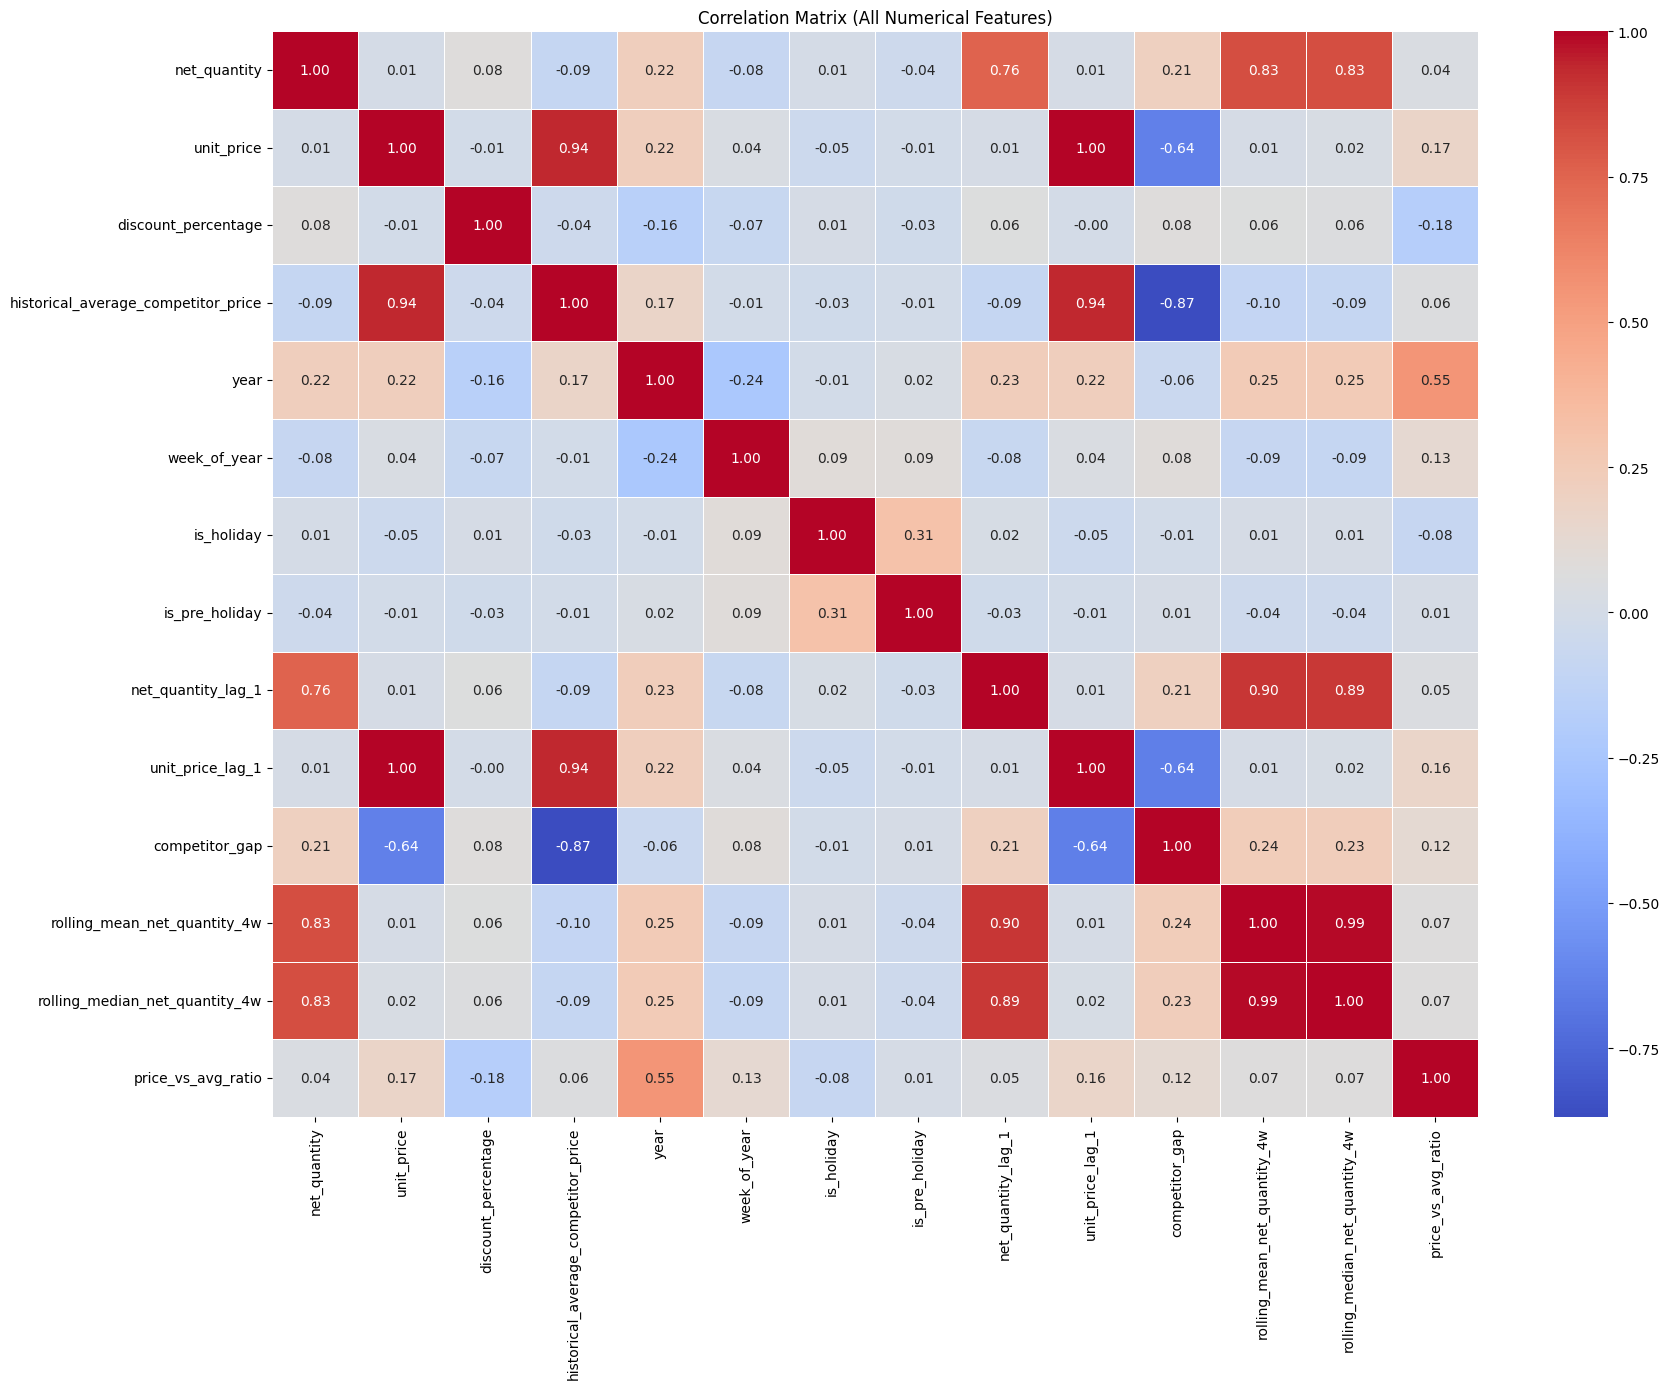

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4. Automatically select all numerical columns
numerical_df = df_weekly.select_dtypes(include=['number'])

# Optional: drop columns you don't want (e.g., IDs)
exclude_cols = []  # e.g., ['id']
numerical_df = numerical_df.drop(columns=[col for col in exclude_cols if col in numerical_df.columns])

# Check
print(f"Using {numerical_df.shape[1]} numerical columns for correlation")

# Compute correlation matrix
correlation_matrix = numerical_df.corr()

# 5. Plot heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlation Matrix (All Numerical Features)')
plt.tight_layout()
plt.show()

In [34]:
df_weekly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1709 entries, 1168 to 696
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   product                              1709 non-null   object        
 1   product_type                         1709 non-null   object        
 2   date                                 1709 non-null   datetime64[ns]
 3   net_quantity                         1709 non-null   int64         
 4   unit_price                           1709 non-null   float64       
 5   discount_percentage                  1709 non-null   float64       
 6   historical_average_competitor_price  1709 non-null   float64       
 7   year                                 1709 non-null   int32         
 8   week_of_year                         1709 non-null   int64         
 9   is_holiday                           1709 non-null   int64         
 10  is_pre_holiday 

In [35]:
# CHRONOLOGICAL SPLIT ---
split_idx = int(len(df_weekly) * 0.8)
train_df = df_weekly.iloc[:split_idx]
test_df = df_weekly.iloc[split_idx:]

# Define X (features) and y (target)
X_train = train_df.drop(columns=['net_quantity', 'date'])
y_train = np.log1p(train_df['net_quantity'])

X_test = test_df.drop(columns=['net_quantity', 'date'])
y_test = np.log1p(test_df['net_quantity'])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


print("Data splitting completed successfully.")

X_train shape: (1367, 15)
X_test shape: (342, 15)
y_train shape: (1367,)
y_test shape: (342,)
Data splitting completed successfully.


In [36]:
df_weekly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1709 entries, 1168 to 696
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   product                              1709 non-null   object        
 1   product_type                         1709 non-null   object        
 2   date                                 1709 non-null   datetime64[ns]
 3   net_quantity                         1709 non-null   int64         
 4   unit_price                           1709 non-null   float64       
 5   discount_percentage                  1709 non-null   float64       
 6   historical_average_competitor_price  1709 non-null   float64       
 7   year                                 1709 non-null   int32         
 8   week_of_year                         1709 non-null   int64         
 9   is_holiday                           1709 non-null   int64         
 10  is_pre_holiday 

In [37]:
# FEATURE PREPROCESSING (ENCODING) ---
# Identify columns
categorical_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns
numerical_cols = X_train.select_dtypes(exclude=['object', 'category', 'string']).columns

# Instantiate and Fit ONLY on Train
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[categorical_cols])

# Transform both sets
encoded_names = ohe.get_feature_names_out(categorical_cols)

# Create Encoded DataFrames
X_train_cat = pd.DataFrame(ohe.transform(X_train[categorical_cols]), columns=encoded_names, index=X_train.index)
X_test_cat = pd.DataFrame(ohe.transform(X_test[categorical_cols]), columns=encoded_names, index=X_test.index)

# Combine with Numerical Features
X_train = pd.concat([X_train[numerical_cols], X_train_cat], axis=1)
X_test = pd.concat([X_test[numerical_cols], X_test_cat], axis=1)

# Ensure string column names 
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)



Training and evaluating Random Forest Regressor...

Random Forest Regression Metrics:
  MAE: 4.4910
  MSE: 52.6319
  RMSE: 7.2548
  MAPE: 97.7786%
  R2 Score: 0.7310


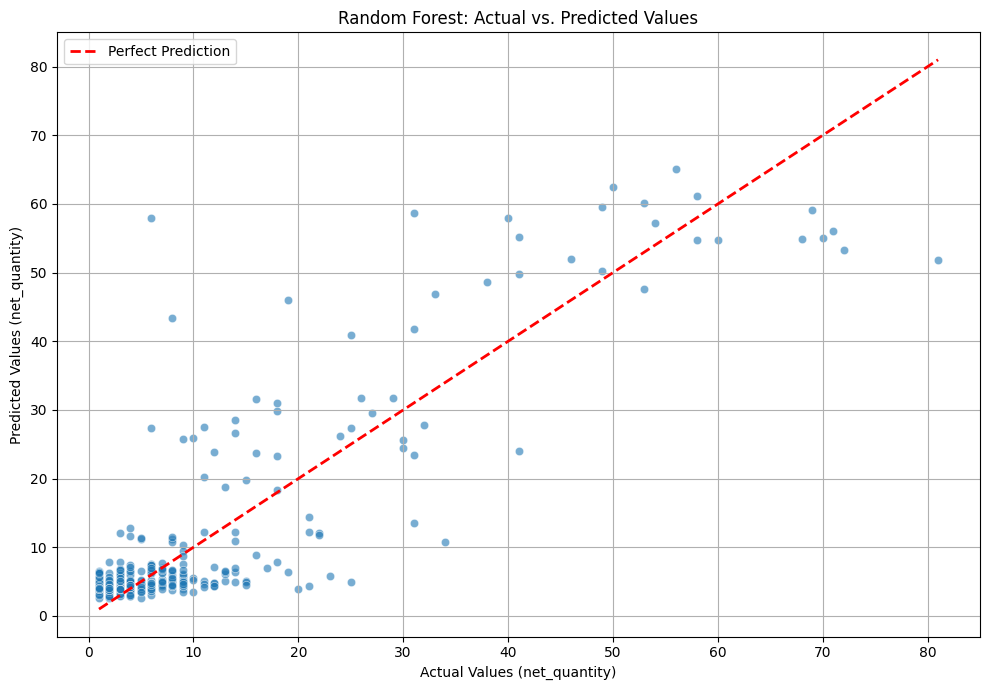

Random Forest Regressor training and evaluation completed.


In [38]:
print("Training and evaluating Random Forest Regressor...")

# 1. Import necessary libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Instantiate a RandomForestRegressor model
rf_model = RandomForestRegressor(random_state=42, max_depth=10, min_samples_leaf=4, n_estimators=200)

# 3. Train the model
rf_model.fit(X_train, y_train)

# 4. Make predictions on X_test_processed

y_pred_rf = rf_model.predict(X_test)
y_test_rf = np.expm1(y_test)
y_pred_rf = np.expm1(y_pred_rf).clip(min=0)

# 5. Calculate MAE
mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)

# 6. Calculate MSE
mse_rf = mean_squared_error(y_test_rf, y_pred_rf)

# 7. Calculate RMSE
rmse_rf = np.sqrt(mse_rf)

# 8. Calculate MAPE
# Avoid division by zero for y_test values that are 0
y_test_for_mape = y_test_rf.copy()
y_test_for_mape[y_test_for_mape == 0] = np.nan # Replace 0 with NaN
mape_rf = np.nanmean(np.abs((y_test_for_mape - y_pred_rf) / y_test_for_mape)) * 100

# 9. Calculate R2 Score
r2_rf = r2_score(y_test_rf, y_pred_rf)

# 10. Print all calculated metrics
print(f"\nRandom Forest Regression Metrics:")
print(f"  MAE: {mae_rf:.4f}")
print(f"  MSE: {mse_rf:.4f}")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  MAPE: {mape_rf:.4f}%")
print(f"  R2 Score: {r2_rf:.4f}")

# 11. Create a scatter plot to visualize actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_rf, y=y_pred_rf, alpha=0.6)

# 12. Add a diagonal line representing perfect predictions
min_val = min(y_test_rf.min(), y_pred_rf.min())
max_val = max(y_test_rf.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

# 13. Label axes and add title
plt.title('Random Forest: Actual vs. Predicted Values')
plt.xlabel('Actual Values (net_quantity)')
plt.ylabel('Predicted Values (net_quantity)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


print("Random Forest Regressor training and evaluation completed.")

In [39]:
print("Defining hyperparameter grids...")

# 1. Define hyperparameter grid for Random Forest Regressor
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None], # None means full depth
    'min_samples_leaf': [1, 2, 4]
}

# 3. Print both dictionaries to display the defined hyperparameter grids
print("\nRandom Forest Hyperparameter Grid:")
print(rf_param_grid)
print("Hyperparameter grids defined successfully.")

Defining hyperparameter grids...

Random Forest Hyperparameter Grid:
{'n_estimators': [100, 200, 300], 'max_depth': [10, 20, None], 'min_samples_leaf': [1, 2, 4]}
Hyperparameter grids defined successfully.


In [40]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def prepare_weekly_data(df_original):
    df = df_original.copy()
    
    # 1. Ensure correct types
    df['date'] = pd.to_datetime(df['date'])

    # 2. Standardize to Weekly (Mondays)
    df['week_start'] = df['date'].dt.to_period('W').dt.start_time



    # 3. Aggregation Dictionary
    agg_dict = {
        'net_quantity': 'sum',
        'unit_price': 'mean',
        'discount_percentage': 'mean',
        'historical_average_competitor_price': 'mean'
    }
    train_price_stats = df.groupby('product')['unit_price'].median().to_dict()
    # Group by both Product and the new Week column
    df_weekly = df.groupby(['product', 'product_type', 'week_start']).agg(agg_dict).reset_index()
    df_weekly = df_weekly.rename(columns={'week_start': 'date'}).sort_values(['product', 'date'])

    # 4. Feature Engineering
    df_weekly['year'] = df_weekly['date'].dt.year
    df_weekly['week_of_year'] = df_weekly['date'].dt.isocalendar().week.astype(int)

    ke_holidays = holidays.Kenya(years=[2020, 2021, 2022, 2023, 2024])
    def get_holiday_features(dt):
        h_name = ke_holidays.get(dt)
        return h_name
    df_weekly['holiday_name'] = df_weekly['date'].apply(get_holiday_features)
    df_weekly['is_holiday'] = df_weekly['holiday_name'].notnull().astype(int)

    # 4. Create the "Pre-Holiday" flag (Day before)

    df_weekly['is_pre_holiday'] = df_weekly['date'].apply(lambda x: 1 if (x + pd.Timedelta(days=1)) in ke_holidays else 0)
  
    df_weekly = df_weekly.drop(columns=['holiday_name'])
    
    # Lagged features (Look-back)
    grouped = df_weekly.groupby('product')
    for i in [1]:
        df_weekly[f'net_quantity_lag_{i}'] = grouped['net_quantity'].shift(i)
        df_weekly[f'unit_price_lag_{i}'] = grouped['unit_price'].shift(i)

    # Competitor Price Gap (How much cheaper/more expensive were we than the average competitor?)
    df_weekly['competitor_gap'] = df_weekly['unit_price'] - df_weekly['historical_average_competitor_price']

    # Rolling 4-week mean and median to capture recent momentum
    for i in [4]:
       df_weekly[f'rolling_net_quantity_{i}w'] = grouped['net_quantity'].transform(lambda x: x.shift(1).rolling(window=i, min_periods=1).mean())
       df_weekly[f'rolling_median_net_quantity_{i}w'] = grouped['net_quantity'].transform(lambda x: x.shift(1).rolling(window=i, min_periods=1).median())
	  
    # 2. Price vs Own History     
    df_weekly['price_vs_avg_ratio'] = df_weekly['unit_price'] / (grouped['unit_price'].transform('mean') + 1e-6)    

    # We fill NaNs using the median of that SPECIFIC product.  
    cols_to_fill = [col for col in df_weekly.columns if 'lag' in col or 'rolling' in col or 'gap' in col]
    
    for col in cols_to_fill:
        df_weekly[col] = df_weekly.groupby('product')[col].transform(lambda x: x.fillna(x.median() if not x.isna().all() else 0))

    # Final fallback for products with only 1 row of data
    df_weekly = df_weekly.fillna(0)
    
    return df_weekly


#  PREPARE WEEKLY DATA ---
df_weekly = prepare_weekly_data(df) 
df_weekly = df_weekly.sort_values('date')

# CHRONOLOGICAL SPLIT ---
split_idx = int(len(df_weekly) * 0.8)
train_df = df_weekly.iloc[:split_idx]
test_df = df_weekly.iloc[split_idx:]

# Define X (features) and y (target)
X_train = train_df.drop(columns=['net_quantity', 'date'])
y_train = np.log1p(train_df['net_quantity'])

X_test = test_df.drop(columns=['net_quantity', 'date'])
y_test = np.log1p(test_df['net_quantity'])

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


print("Data splitting completed successfully.")

# FEATURE PREPROCESSING (ENCODING) ---
# Identify columns
categorical_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns
numerical_cols = X_train.select_dtypes(exclude=['object', 'category', 'string']).columns

# Instantiate and Fit ONLY on Train
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[categorical_cols])

# Transform both sets
encoded_names = ohe.get_feature_names_out(categorical_cols)

# Create Encoded DataFrames
X_train_cat = pd.DataFrame(ohe.transform(X_train[categorical_cols]), columns=encoded_names, index=X_train.index)
X_test_cat = pd.DataFrame(ohe.transform(X_test[categorical_cols]), columns=encoded_names, index=X_test.index)

# Combine with Numerical Features
X_train = pd.concat([X_train[numerical_cols], X_train_cat], axis=1)
X_test = pd.concat([X_test[numerical_cols], X_test_cat], axis=1)

# Ensure string column names for XGBoost
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)


print("Starting Randomized Search for Random Forest Regressor...")

# 1.  RandomizedSearch works best with a wider range of possibilities
rf_param_dist = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [10, 20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None], 
    'bootstrap': [True, False]
}
tscv = TimeSeriesSplit(n_splits=5)

# 2. Instantiate RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=30, 
    cv=tscv, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1, 
    verbose=1,
    random_state=42
)

# 3. Fit to the preprocessed training data
random_search_rf.fit(X_train, y_train)

print("Randomized Search completed.")

# 4. Retrieve the best estimator
best_rf_model = random_search_rf.best_estimator_
print(f"\nBest parameters for Random Forest: {random_search_rf.best_params_}")

# 5. Make predictions
y_pred_rf_tuned = best_rf_model.predict(X_test)
y_test_rf_tuned = np.expm1(y_test)
y_pred_rf_tuned = np.expm1(y_pred_rf_tuned).clip(min=0)

# 6. Metrics Calculation
mae_rf_tuned = mean_absolute_error(y_test_rf_tuned, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test_rf_tuned, y_pred_rf_tuned))
r2_rf_tuned = r2_score(y_test_rf_tuned, y_pred_rf_tuned)

# Robust MAPE Calculation (avoiding zero division)
mape_rf_tuned = np.mean(np.abs((y_test_rf_tuned - y_pred_rf_tuned) / (y_test_rf_tuned + 1))) * 100

print(f"\nTuned Random Forest Regression Metrics:")
print(f"  MAE: {mae_rf_tuned:.4f}")
print(f"  RMSE: {rmse_rf_tuned:.4f}")
print(f"  MAPE: {mape_rf_tuned:.4f}%")
print(f"  R2 Score: {r2_rf_tuned:.4f}")

# 7. Store performance metrics
rf_tuned_metrics = {
    'model': 'RandomForestRegressor_Tuned',
    'MAE': mae_rf_tuned,
    'RMSE': rmse_rf_tuned,
    'MAPE': mape_rf_tuned,
    'R2': r2_rf_tuned
}

X_train shape: (1367, 15)
X_test shape: (342, 15)
y_train shape: (1367,)
y_test shape: (342,)
Data splitting completed successfully.
Starting Randomized Search for Random Forest Regressor...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


C:\Users\eerkmem\AppData\Local\Temp\ipykernel_19304\1524412746.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week_start'] = df['date'].dt.to_period('W').dt.start_time


Randomized Search completed.

Best parameters for Random Forest: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}

Tuned Random Forest Regression Metrics:
  MAE: 4.1766
  RMSE: 6.7773
  MAPE: 57.0068%
  R2 Score: 0.7652


C:\Users\eerkmem\AppData\Local\Temp\ipykernel_19304\2693306097.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


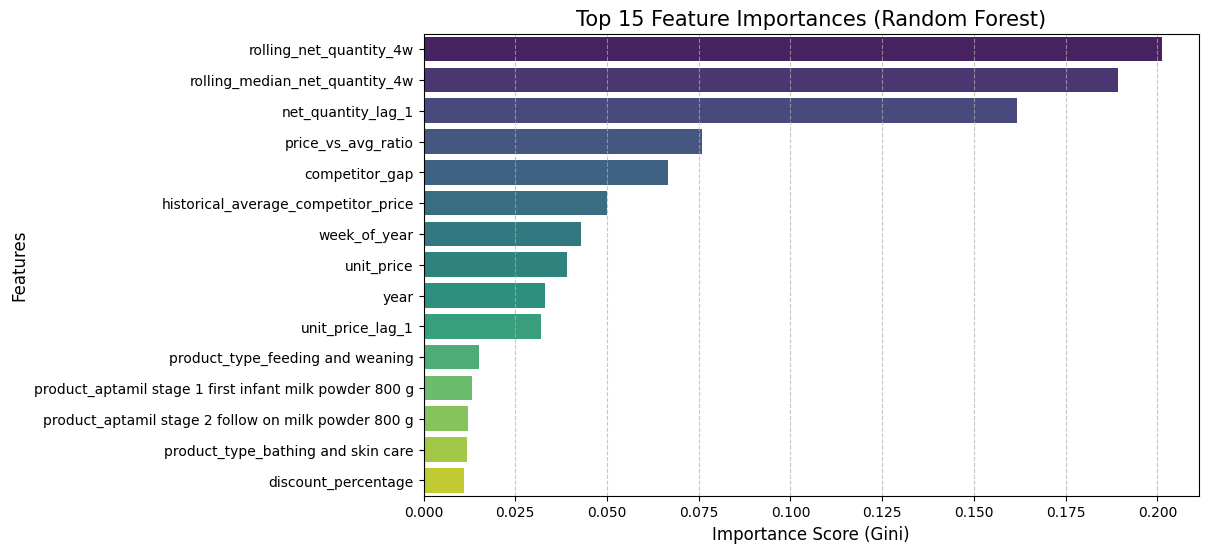

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get feature names and importance scores
features = X_train.columns
importances = best_rf_model.feature_importances_

# 2. Create a DataFrame for sorting
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False).head(15)

# 3. Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')

plt.title('Top 15 Feature Importances (Random Forest)', fontsize=15)
plt.xlabel('Importance Score (Gini)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

🚀 Starting training with TimeSeriesSplit...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

════════════════════════════════════════
════════════════════════════════════════
RMSE : 7.5197 units
R2 Score:  0.7090
MAE:       4.7558 units
MAPE (Adjusted): 67.70%
Best Params: {'tweedie_variance_power': 1.2, 'reg_lambda': 0, 'num_leaves': 20, 'n_estimators': 200, 'min_child_samples': 5, 'learning_rate': 0.05, 'feature_fraction': 0.7}
════════════════════════════════════════


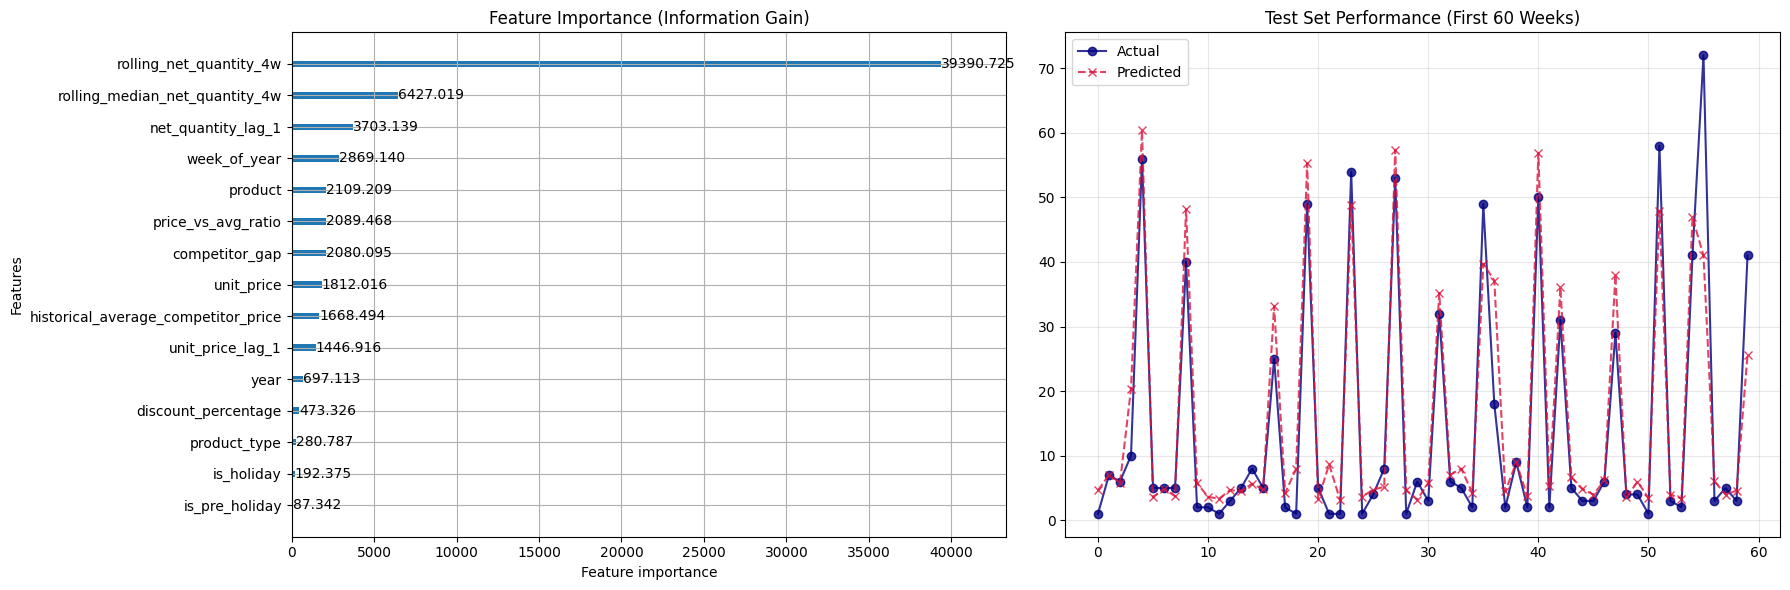

In [42]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# --- 1. Prepare Data & Categoricals ---
df_model = df_weekly.copy().sort_values('date')

# Identify and convert categorical columns
cat_cols = df_model.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
for col in cat_cols:
    df_model[col] = df_model[col].astype('category')

# --- 2. Leakage-Free Chronological Split ---
split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

# Define X and y (Drop the target and the non-feature date column)
X_train = train_df.drop(columns=['net_quantity', 'date'])
y_train = train_df['net_quantity']
X_test = test_df.drop(columns=['net_quantity', 'date'])
y_test = test_df['net_quantity']

# --- 3. Time-Series Aware Hyperparameter Tuning ---
# TimeSeriesSplit prevents "look-ahead" bias during cross-validation
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.03, 0.05],
    'num_leaves': [20, 31, 50],
    'tweedie_variance_power': [1.1, 1.2],
    'min_child_samples': [5, 10, 20],
    'feature_fraction': [0.7, 0.8, 0.9],
    'reg_lambda': [0, 0.1, 0.9]
}

random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(
        objective='tweedie',
        boost_from_average=True,
        importance_type='gain',
        random_state=42,
        verbosity=-1
    ),
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

print("🚀 Starting training with TimeSeriesSplit...")
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_

# --- 4. Evaluation ---
y_pred = best_model.predict(X_test).clip(min=0)
y_test_vals = y_test.values

rmse = np.sqrt(mean_squared_error(y_test_vals, y_pred))

print("\n" + "═"*40)
print("═"*40)
print(f"RMSE : {rmse:.4f} units")  
print(f"R2 Score:  {r2_score(y_test_vals, y_pred):.4f}")
print(f"MAE:       {mean_absolute_error(y_test_vals, y_pred):.4f} units")
mape = np.mean(np.abs((y_test_vals - y_pred) / (y_test_vals + 1))) * 100
print(f"MAPE (Adjusted): {mape:.2f}%")
print(f"Best Params: {random_search.best_params_}")
print("═"*40)

# --- 5. Visualizations ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Feature Importance (Gain)
lgb.plot_importance(best_model, max_num_features=15, importance_type='gain', ax=ax1)
ax1.set_title("Feature Importance (Information Gain)")

# Actual vs Predicted (Zooming into the first 60 points)
ax2.plot(y_test_vals[:60], label='Actual', alpha=0.8, marker='o', color='navy')
ax2.plot(y_pred[:60], label='Predicted', alpha=0.8, linestyle='--', marker='x', color='crimson')
ax2.set_title("Test Set Performance (First 60 Weeks)")
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()




Starting Randomized Search for Poisson XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits


C:\Users\eerkmem\AppData\Local\Temp\ipykernel_19304\1524412746.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['week_start'] = df['date'].dt.to_period('W').dt.start_time


Randomized Search completed.

Best parameters found: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 5, 'colsample_bytree': 0.6}

Tuned Poisson XGBoost Metrics (Random Search):
  MAE: 4.5572
  RMSE: 7.8000
  MAPE: 65.21%
  R2: 0.6890


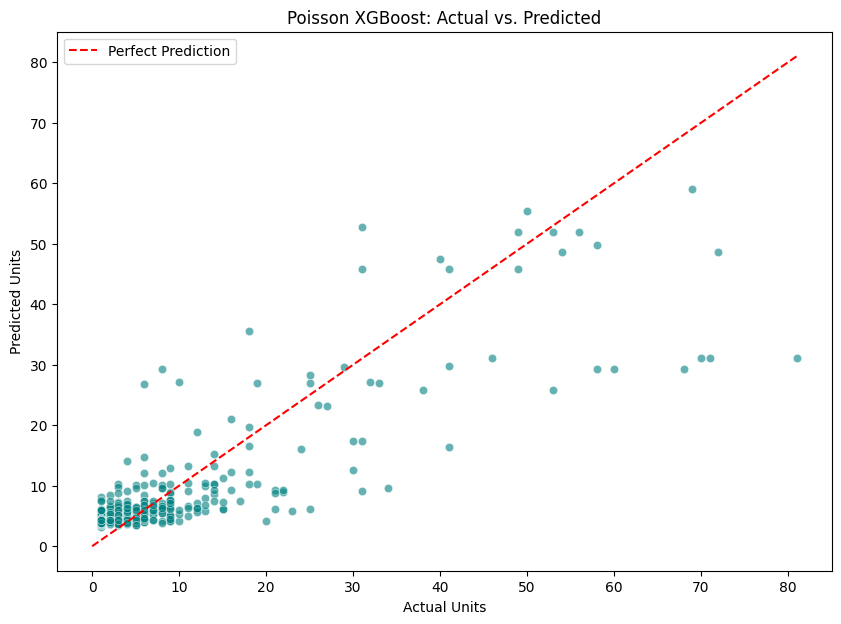

In [43]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit 
from xgboost import XGBRegressor

print("Starting Randomized Search for Poisson XGBoost...")


#  PREPARE WEEKLY DATA ---
df_weekly = prepare_weekly_data(df) 
df_weekly = df_weekly.sort_values('date')

# --- 1. CHRONOLOGICAL SPLIT (NO LOG TRANSFORM) ---
split_idx = int(len(df_weekly) * 0.8)
train_df = df_weekly.iloc[:split_idx]
test_df = df_weekly.iloc[split_idx:]

# Define X (features) and y (target)
X_train = train_df.drop(columns=['net_quantity', 'date'])
y_train = train_df['net_quantity']

X_test = test_df.drop(columns=['net_quantity', 'date'])
y_test = test_df['net_quantity']

# --- 2. FEATURE PREPROCESSING ---
# FEATURE PREPROCESSING (ENCODING) ---
# Identify columns
categorical_cols = X_train.select_dtypes(include=['object', 'category', 'string']).columns
numerical_cols = X_train.select_dtypes(exclude=['object', 'category', 'string']).columns

# Instantiate and Fit ONLY on Train
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[categorical_cols])

# Transform both sets
encoded_names = ohe.get_feature_names_out(categorical_cols)

# Create Encoded DataFrames
X_train_cat = pd.DataFrame(ohe.transform(X_train[categorical_cols]), columns=encoded_names, index=X_train.index)
X_test_cat = pd.DataFrame(ohe.transform(X_test[categorical_cols]), columns=encoded_names, index=X_test.index)

# Combine with Numerical Features
X_train = pd.concat([X_train[numerical_cols], X_train_cat], axis=1)
X_test = pd.concat([X_test[numerical_cols], X_test_cat], axis=1)

# Ensure string column names for XGBoost
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# 1. Define a wider parameter distribution
# RandomizedSearch handles ranges better than fixed lists
param_dist_xgb = {
    'n_estimators': [100, 300, 500, 700],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5]
}

tscv = TimeSeriesSplit(n_splits=5)
# 2. Instantiate RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=XGBRegressor(
        random_state=42, 
        objective='count:poisson', 
        eval_metric='poisson-nloglik',
    ),
    param_distributions=param_dist_xgb,
    n_iter=30, 
    cv=tscv, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# 3. Fit to the preprocessed training data
# Note: y_train must be the raw counts for Poisson
random_search_xgb.fit(X_train, y_train)

print("Randomized Search completed.")

# 4. Retrieve and Evaluate
best_xgb_model = random_search_xgb.best_estimator_
print(f"\nBest parameters found: {random_search_xgb.best_params_}")

# 5. Predictions
y_pred_orig = best_xgb_model.predict(X_test).clip(min=0)
y_test_orig = y_test.values

# 6. Metrics
mae = mean_absolute_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
r2 = r2_score(y_test_orig, y_pred_orig)
mape = np.mean(np.abs((y_test_orig - y_pred_orig) / (y_test_orig + 1))) * 100

print(f"\nTuned Poisson XGBoost Metrics (Random Search):")
print(f"  MAE: {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  MAPE: {mape:.2f}%")
print(f"  R2: {r2:.4f}")

# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_orig, y=y_pred_orig, alpha=0.6, color='teal')
line_limit = max(y_test_orig.max(), y_pred_orig.max())
plt.plot([0, line_limit], [0, line_limit], 'r--', label='Perfect Prediction')
plt.title('Poisson XGBoost: Actual vs. Predicted')
plt.xlabel('Actual Units')
plt.ylabel('Predicted Units')
plt.legend()
plt.show()

In [44]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class PreprocessingPipeline(BaseEstimator, TransformerMixin):
    def __init__(self, ohe_fitted_instance, numerical_cols_train, categorical_cols_train, final_column_order):
        self.ohe = ohe_fitted_instance
        self.numerical_cols_train = numerical_cols_train
        self.categorical_cols_train = categorical_cols_train
        self.final_column_order = final_column_order
        self.encoded_feature_names = self.ohe.get_feature_names_out(self.categorical_cols_train)

    def fit(self, X, y=None):
        return self  # already fitted externally

    def transform(self, X):
        # If dict passed, convert to DataFrame
        if isinstance(X, dict):
            X = pd.DataFrame([X])
        elif isinstance(X, pd.Series):
            X = pd.DataFrame([X])
        
        X_copy = X.copy()
        
        # Drop any irrelevant columns if present
        X_copy = X_copy.drop(columns=[col for col in ['date', 'net_quantity'] if col in X_copy.columns], errors='ignore')

        # Separate categorical and numerical
        X_cat = X_copy[self.categorical_cols_train].copy()
        X_num = X_copy[self.numerical_cols_train].copy()
        
        # Encode categorical
        X_cat_encoded = self.ohe.transform(X_cat)
        X_cat_df = pd.DataFrame(X_cat_encoded, columns=self.encoded_feature_names, index=X_copy.index)
        
        # Combine numerical + encoded
        processed_df = pd.concat([X_num, X_cat_df], axis=1)

        # Align to exact columns from training
        final_df = pd.DataFrame(0, index=processed_df.index, columns=self.final_column_order)
        for col in processed_df.columns:
            if col in final_df.columns:
                final_df[col] = processed_df[col]

        # Ensure correct dtypes from training
        for col in final_df.columns:
            if col in X_copy.columns and np.issubdtype(X_copy[col].dtype, np.number):
                final_df[col] = final_df[col].astype(X_copy[col].dtype)
        return final_df
    
preprocess_pipeline = PreprocessingPipeline(
    ohe_fitted_instance=ohe,     
    numerical_cols_train=numerical_cols.tolist(),   
    categorical_cols_train=categorical_cols.tolist(), 
    final_column_order=X_train.columns.tolist() 
)

In [107]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar
import holidays
import matplotlib.pyplot as plt

class PriceOptimizerDefault:
    def __init__(self, model, pipeline, historical_df, train_price_stats, config=None):
        self.model = model
        self.pipeline = pipeline
        self.history = historical_df.copy()
        self.history['product_lookup'] = self.history['product'].str.lower().str.strip()
        self.train_price_stats = train_price_stats
        
        self.ke_holidays = holidays.Kenya(years=list(range(2020, 2027)))
        self.config = config or {
            'max_discount': 0.15,
            'max_premium': 0.20,
            'demand_floor': 0.1
        }

    def build_scenario_features(self, product, date, target_price, competitor_price=None):
        product_clean = product.lower().strip()
        hist = self.history[self.history['product_lookup'] == product_clean].sort_values('date')
        
        if hist.empty:
            raise ValueError(f"Product '{product}' not found in history.")
        
        last_row = hist.iloc[-1]
        current_date = pd.to_datetime(date)
        
        row = {
            'product': last_row['product'],
            'product_type': last_row['product_type'],
            'unit_price': target_price,
            'historical_average_competitor_price': competitor_price if competitor_price is not None else last_row['historical_average_competitor_price'],
            'year': current_date.year,
            'week_of_year': int(current_date.isocalendar()[1]),
            'is_holiday': 1 if self.ke_holidays.get(current_date) else 0,
            'is_pre_holiday': 1 if (current_date + pd.Timedelta(days=1)) in self.ke_holidays else 0,
            'net_quantity_lag_1': last_row.get('net_quantity', 0),
            'unit_price_lag_1': last_row.get('unit_price', 0),
            'rolling_net_quantity_4w': hist['net_quantity'].tail(4).mean(),
            'rolling_median_net_quantity_4w': hist['net_quantity'].tail(4).median(),
            'competitor_gap': target_price - (competitor_price if competitor_price is not None else last_row['historical_average_competitor_price']),
            'price_vs_avg_ratio': target_price / (self.train_price_stats.get(product_clean, last_row['unit_price']) + 1e-6),
            'discount_percentage': 0
        }
        return pd.DataFrame([row])

    def predict_demand(self, product_name, price, date=pd.Timestamp.now(), competitor_price=None):
        df_row = self.build_scenario_features(product_name, date, price, competitor_price)
        processed_X = self.pipeline.transform(df_row)
        pred_log = self.model.predict(processed_X)[0]
        pred_units = np.expm1(pred_log)
        return max(self.config['demand_floor'], pred_units)

    def optimize_product(self, product_name, current_price, competitor_price=None, verbose=True):
        lower = current_price * (1 - self.config['max_discount'])
        upper = current_price * (1 + self.config['max_premium'])
        
        def objective(p):
            return -(self.predict_demand(product_name, float(p), competitor_price=competitor_price) * p)

        res = minimize_scalar(objective, bounds=(lower, upper), method='bounded')
        opt_price = float(res.x)
        
        demand_current = self.predict_demand(product_name, current_price, competitor_price=competitor_price)
        demand_opt = self.predict_demand(product_name, opt_price, competitor_price=competitor_price)
        
        result = {
            'product': product_name,
            'current_price': round(current_price, 2),
            'optimal_price': round(opt_price, 2),
            'current_demand': round(demand_current, 2),
            'expected_demand_opt': round(demand_opt, 2),
            'revenue_lift_pct': round(((demand_opt * opt_price) / (demand_current * current_price + 1e-6) - 1) * 100, 2)
        }

        if verbose:
            self._plot_results(product_name, lower, upper, opt_price, current_price, competitor_price)
        return result
    
    

    def _plot_results(self, product, low, high, opt, current, competitor_price=None):
        prices = np.linspace(low, high, 20)
        demands = [self.predict_demand(product, p, competitor_price=competitor_price) for p in prices]
        revenues = [p*d for p,d in zip(prices, demands)]
        
        fig, ax1 = plt.subplots(figsize=(10,5))
        ax1.plot(prices, demands, 'b--', label='Demand')
        ax2 = ax1.twinx()
        ax2.plot(prices, revenues, 'g-', label='Revenue', linewidth=3)
        ax1.axvline(opt, color='red', linestyle='--', label=f'Optimal: {opt:.0f}')
        ax1.axvline(current, color='black', linestyle=':', label='Current')
        ax1.set_ylabel('Demand', color='b')
        ax2.set_ylabel('Revenue', color='g')
        plt.title(f"Price Optimization: {product}")
        fig.tight_layout()
        plt.show()

In [47]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar
import holidays
import matplotlib.pyplot as plt

class PriceOptimizer:
    def __init__(self, model, pipeline, historical_df, train_price_stats, config=None):
        self.model = model
        self.pipeline = pipeline
        self.history = historical_df.copy()
        self.history['product_lookup'] = self.history['product'].str.lower().str.strip()
        self.train_price_stats = train_price_stats
        
        self.ke_holidays = holidays.Kenya(years=list(range(2020, 2027)))
        self.config = config or {
            'max_discount': 0.20,
            'max_premium': 0.30,
            'demand_floor': 1
        }

    def build_scenario_features(self, product, date, target_price, competitor_price=None):
        product_clean = product.lower().strip()
        hist = self.history[self.history['product_lookup'] == product_clean].sort_values('date')
        
        if hist.empty:
            raise ValueError(f"Product '{product}' not found in history.")
        
        last_row = hist.iloc[-1]
        current_date = pd.to_datetime(date)
        
        row = {
            'product': last_row['product'],
            'product_type': last_row['product_type'],
            'unit_price': target_price,
            'historical_average_competitor_price': competitor_price if competitor_price is not None else last_row['historical_average_competitor_price'],
            'year': current_date.year,
            'week_of_year': int(current_date.isocalendar()[1]),
            'is_holiday': 1 if self.ke_holidays.get(current_date) else 0,
            'is_pre_holiday': 1 if (current_date + pd.Timedelta(days=1)) in self.ke_holidays else 0,
            'net_quantity_lag_1': last_row.get('net_quantity', 0),
            'unit_price_lag_1': last_row.get('unit_price', 0),
            'rolling_net_quantity_4w': hist['net_quantity'].tail(4).mean(),
            'rolling_median_net_quantity_4w': hist['net_quantity'].tail(4).median(),
            'competitor_gap': target_price - (competitor_price if competitor_price is not None else last_row['historical_average_competitor_price']),
            'price_vs_avg_ratio': target_price / (self.train_price_stats.get(product_clean, last_row['unit_price']) + 1e-6),
            'discount_percentage': 0
        }
        return pd.DataFrame([row])
    
    def predict_demand(self, product_name, price, date=pd.Timestamp.now(), competitor_price=None, elasticity=0.0, comp_elasticity=0.0):
        df_row = self.build_scenario_features(product_name, date, price, competitor_price)
        processed_X = self.pipeline.transform(df_row)
        pred_log = self.model.predict(processed_X)[0]
        base_units = np.expm1(pred_log)
    
    # Own-price sensitivity: higher price reduces demand
        base_price = self.train_price_stats.get(product_name.lower().strip(), price)
        adjusted_units = base_units * (base_price / price) ** abs(elasticity)
    
    # Competitor price effect: higher competitor price increases demand
        if competitor_price is not None:
            adjusted_units *= (competitor_price / price) ** comp_elasticity
    
        return max(self.config['demand_floor'], adjusted_units)

    def optimize_product(self, product_name, current_price, competitor_price=None, verbose=True):
        product_clean = product_name.lower().strip()
        historical_avg = self.train_price_stats.get(product_clean)
        
        # Historical floor enforcement
        min_pct = 0.7  # 70% of historical average
        if historical_avg is not None and current_price < min_pct * historical_avg:
            raise ValueError(
                f"Current price {current_price} is below allowed minimum "
                f"({min_pct*100:.0f}% of historical avg {historical_avg:.2f} = {min_pct*historical_avg:.2f})"
            )
    
        lower = max(current_price * (1 - self.config['max_discount']), min_pct * historical_avg)
        upper = current_price * (1 + self.config['max_premium'])
        
        #def objective(p):
        #    return -(self.predict_demand(product_name, float(p), competitor_price=competitor_price) * p)
        def objective(p):
            return -(self.predict_demand(product_name, float(p), competitor_price=competitor_price, elasticity=self.config.get('elasticity', 0.0), comp_elasticity=self.config.get('comp_elasticity', 0.0)) * p)
    
          
        res = minimize_scalar(objective, bounds=(lower, upper), method='bounded')
        opt_price = float(res.x)
        
        demand_current = self.predict_demand(
            product_name, current_price, competitor_price=competitor_price,
            elasticity=self.config.get('elasticity', 0.0),
            comp_elasticity=self.config.get('comp_elasticity', 0.0)
        )
        demand_opt = self.predict_demand(
            product_name, opt_price, competitor_price=competitor_price,
            elasticity=self.config.get('elasticity', 0.0),
            comp_elasticity=self.config.get('comp_elasticity', 0.0)
        )
        
        result = {
            'product': product_name,
            'current_price': round(current_price, 2),
            'optimal_price': round(opt_price, 2),
            'current_demand': round(demand_current, 2),
            'expected_demand_opt': round(demand_opt, 2),
            'revenue_lift_pct': round(((demand_opt * opt_price) / (demand_current * current_price + 1e-6) - 1) * 100, 2)
        }
    
        if verbose:
            self._plot_results(product_name, lower, upper, opt_price, current_price, competitor_price)
        return result
    

    def _plot_results(self, product, low, high, opt, current, competitor_price=None):
        prices = np.linspace(low, high, 20)
        demands = [self.predict_demand(product, p, competitor_price=competitor_price) for p in prices]
        revenues = [p*d for p,d in zip(prices, demands)]
        
        fig, ax1 = plt.subplots(figsize=(10,5))
        ax1.plot(prices, demands, 'b--', label='Demand')
        ax2 = ax1.twinx()
        ax2.plot(prices, revenues, 'g-', label='Revenue', linewidth=3)
        ax1.axvline(opt, color='red', linestyle='--', label=f'Optimal: {opt:.0f}')
        ax1.axvline(current, color='black', linestyle=':', label='Current')
        ax1.set_ylabel('Demand', color='b')
        ax2.set_ylabel('Revenue', color='g')
        plt.title(f"Price Optimization: {product}")
        fig.tight_layout()
        plt.show()

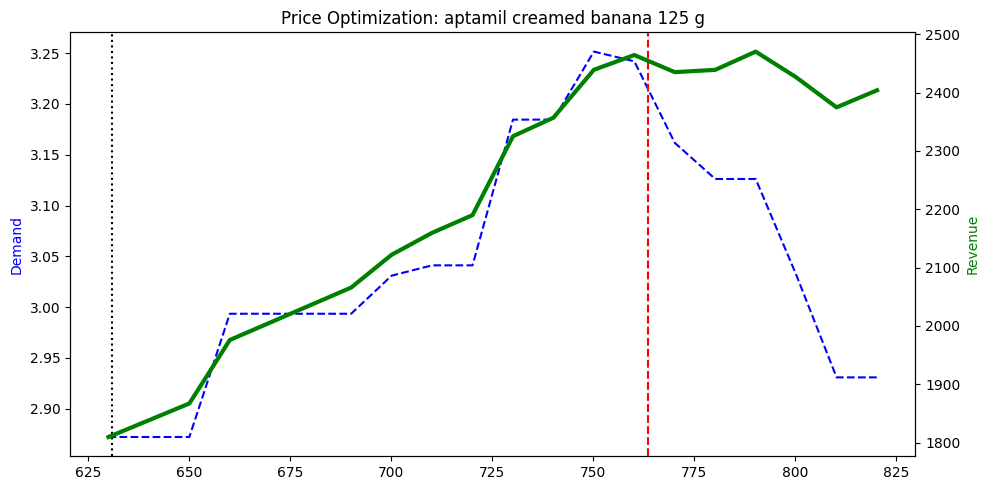

📦 Product: aptamil creamed banana 125 g
💰 Current Price: KSh 631.00
💵 Optimal Price: KSh 763.47
📈 Current Demand: 2.87 units
📊 Expected Demand at Optimal Price: 3.24 units
🚀 Expected Revenue Lift: 36.57%


In [48]:

optimizer = PriceOptimizer(
    model=best_rf_model,
    pipeline=preprocess_pipeline,
    historical_df=df_weekly,
    train_price_stats=train_price_stats
)

try:
    result = optimizer.optimize_product(
        product_name="aptamil creamed banana 125 g",
        current_price=631,
        competitor_price=1300
    )

    print(f"📦 Product: {result['product']}")
    print(f"💰 Current Price: KSh {result['current_price']:.2f}")
    print(f"💵 Optimal Price: KSh {result['optimal_price']:.2f}")
    print(f"📈 Current Demand: {float(result['current_demand']):.2f} units")
    print(f"📊 Expected Demand at Optimal Price: {float(result['expected_demand_opt']):.2f} units")
    print(f"🚀 Expected Revenue Lift: {float(result['revenue_lift_pct']):.2f}%")

except ValueError as e:
    print(f"⚠️ Optimization Error: {e}")